## Lecture 3 - Milestones (1-4)
### Milestone 1 (Function-level Profiling) 

In [ ]:
"""
Mandelbrot Set Generator
Author : [ Mathias Jørgensen ]
Course : Numerical Scientific Computing 2026
"""
import numpy as np
import matplotlib.pyplot as plt
import time
import cProfile
import pstats
import sys
from pathlib import Path

# Adds mandelbrot-nsc to sys.path so lecture_files can be imported
sys.path.append(str(Path("..").resolve()))

import lecture_py_files.mandelbrot_1_2 as mb12

In [2]:
# Parameters
x_dim = (-2, 1)
y_dim = (-1.5, 1.5)
res = (512, 512)

#Using cProfile on both naive and numpy function
cProfile.run('mb12.compute_mandelbrot_naive(x_dim, y_dim, res)',
                'naive_profile.prof')
cProfile.run('mb12.compute_mandelbrot_numpy(x_dim, y_dim, res)',
                'numpy_profile.prof')

for name in ('naive_profile.prof', 'numpy_profile.prof'):
    stats = pstats.Stats(name)
    stats.sort_stats('cumulative')
    stats.print_stats(10)


Sat Apr 25 13:15:52 2026    naive_profile.prof

         5743705 function calls in 3.643 seconds

   Ordered by: cumulative time
   List reduced from 20 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    3.643    3.643 {built-in method builtins.exec}
        1    0.000    0.000    3.643    3.643 <string>:1(<module>)
        1    0.718    0.718    3.642    3.642 C:\UNI\8.Semester\numerical_scientific_computing\mandelbrot-nsc\lecture_py_files\mandelbrot_1_2.py:75(compute_mandelbrot_naive)
   262144    2.329    0.000    2.924    0.000 C:\UNI\8.Semester\numerical_scientific_computing\mandelbrot-nsc\lecture_py_files\mandelbrot_1_2.py:43(mandelbrot_point_naive)
  5481530    0.595    0.000    0.595    0.000 {built-in method builtins.abs}
        2    0.000    0.000    0.000    0.000 c:\Users\mathi\miniforge3\envs\nsc2026\Lib\site-packages\numpy\_core\function_base.py:26(linspace)
        1    0.000    0.000    

Questions to answer:

1. Which function takes most total time?
    mandelbrot_point_naive for the naive approach.
    Compute_mandelbrot_numpy for the numpy approach.

2. Are there functions called surprisingly many times?
    No only in naive approach it has called mandelbrot_point_naive many times, but that is expectable.

3. How does the NumPy profile compare to naive?
    Faster, less function calls and less overall time.

4. Where does NumPy spend its time?
    Almost all time is spend inside the function compute_mandelbrot_numpy


### Milestone 2 (Line-level Profiling)
Wrote profile results to 'mandelbrot_3.py.lprof'
Timer unit: 1e-06 s

Total time: 10.1513 s
File: .\mandelbrot_3.py
Function: compute_mandelbrot_naive at line 26

Line #      Hits         Time  Per Hit   % Time  Line Contents
==============================================================
    26                                           @profile
    27                                           def compute_mandelbrot_naive(x_dim = tuple[float, float],
    28                                                                        y_dim = tuple[float, float],
    29                                                                        res_x = int,
    30                                                                        res_y = int,
    31                                                                        max_iter=100):
    32
    33                                               # Pulling out variables from tuples
    34         1          4.6      4.6      0.0      x_min, x_max = x_dim
    35         1          0.4      0.4      0.0      y_min, y_max = y_dim
    36
    37                                               # Create 1D arrays
    38         1         86.9     86.9      0.0      x = np.linspace(x_min, x_max, res_x)
    39         1         28.6     28.6      0.0      y = np.linspace(y_min, y_max, res_y)
    40         1         21.6     21.6      0.0      result = np.zeros((res_y, res_x), dtype=int)
    41
    42       513        118.9      0.2      0.0      for i in range(res_y):
    43    262656      82268.6      0.3      0.8          for j in range(res_x):
    44    262144    1424432.9      5.4     14.0              c = x[j] + 1j * y[i]
    45    262144      74211.4      0.3      0.7              z = 0
    46   5743674    1510219.7      0.3     14.9              for n in range(max_iter):
    47   5698796    3376748.8      0.6     33.3                  if abs(z) > 2:
    48    217266     197393.7      0.9      1.9                      result[i, j] = n
    49    217266      69766.0      0.3      0.7                      break
    50   5481530    3346907.8      0.6     33.0                  z = z*z + c
    51                                                       else:
    52     44878      69124.8      1.5      0.7                  result[i, j] = max_iter
    53         1          0.8      0.8      0.0      return result

Add a profiling section to your MP1 mini-report. In your own words, answer:
1. cProfile on naive vs NumPy: How many functions appear in each profile? What does this difference tell you about where the work actually happens?
    20 functions appear in naive, while 38 appear in numpy. The work is primarily within the functions and in abs(z) > 2

2. line profiler on naive: Which lines dominate runtime? What fraction of total time is spent in the inner loop?
    Line 47 and line 50, with (if abs(z) > 2) and (z = z*z + c)

3. Based on your profiling results: why is NumPy faster than naive Python?
    The number of function calls are far less for numpy (73 function calls) than in the naive python approach (5743705 function calls)

4. What would you need to change to make the naive version faster? (hint: what does line profiler tell you about the inner loop?)
    Especially change line 47 and 50

### Milestone 3 - Numba Implementation
Implement & compare hybrid and fully compiled approaches

In [3]:
import lecture_py_files.mandelbrot_3 as mb3
# Parameters
iterations = 10
x_dim = (-2, 1)
y_dim = (-1.5, 1.5)
resolution_1 = (64, 64)
resolution_2 = (1024, 1024)

# Warm up: First computation doesnt count
_ = mb3.compute_mandelbrot_hybrid(x_dim=x_dim, y_dim=y_dim, res=resolution_1)
_ = mb3.compute_mandelbrot_full(x_dim=x_dim, y_dim=y_dim, res=resolution_1)

# Benchmark and plots of numba approach
t_hybrid, _ = mb12.benchmark(mb3.compute_mandelbrot_hybrid, x_dim, y_dim, resolution_2, n_runs=iterations)
t_full, _ = mb12.benchmark(mb3.compute_mandelbrot_full, x_dim, y_dim, resolution_2, n_runs=iterations)

mb12.compute_mandelbrot_naive(x_dim, y_dim, resolution_2)
print(f'Hybrid: {t_hybrid:.3f} seconds')
print(f'Fully compiled: {t_full:.3f} seconds')
print(f'Ratio: {t_hybrid/t_full:.1f}x')

compute_mandelbrot_hybrid: Median: 2.7000s(min=2.2624, max=2.8926)
compute_mandelbrot_full: Median: 0.0712s(min=0.0707, max=0.0716)
Hybrid: 2.700 seconds
Fully compiled: 0.071 seconds
Ratio: 37.9x


Milestone 3 - Benchmark Naive, Numpy and Numba version

In [4]:
# Parameters
iterations = 10
x_dim = (-2, 1)
y_dim = (-1.5, 1.5)
resolution_1 = (64, 64)
resolution_2 = (1024, 1024)

# Warm up: First computation doesnt count
_ = mb3.compute_mandelbrot_full(x_dim, y_dim, resolution_1)

# Benchmark and plots of numba approach
t_naive, _ = mb12.benchmark(mb12.compute_mandelbrot_naive, x_dim, y_dim, resolution_2, n_runs=iterations)
t_numpy, _ = mb12.benchmark(mb12.compute_mandelbrot_numpy, x_dim, y_dim, resolution_2, n_runs=iterations)
t_numba, _ = mb12.benchmark(mb3.compute_mandelbrot_full, x_dim, y_dim, resolution_2, n_runs=iterations)

print(f'Naive: {t_naive:.3f} seconds')
print(f'Numpy: {t_numpy:.3f} seconds. Ratio: ({t_naive/t_numpy})x')
print(f'Numba: {t_numba:.3f} seconds. Ratio: ({t_naive/t_numba})x')

compute_mandelbrot_naive: Median: 8.3512s(min=8.2600, max=8.9090)
compute_mandelbrot_numpy: Median: 1.8900s(min=1.8622, max=2.0469)
compute_mandelbrot_full: Median: 0.0741s(min=0.0712, max=0.0786)
Naive: 8.351 seconds
Numpy: 1.890 seconds. Ratio: (4.418560715134805)x
Numba: 0.074 seconds. Ratio: (112.67942543273413)x


### Milestone 4 - Test float32 and float64 Precisions

float32: 0.417s
float64: 0.284s
Max diff float32 vs float64: 33


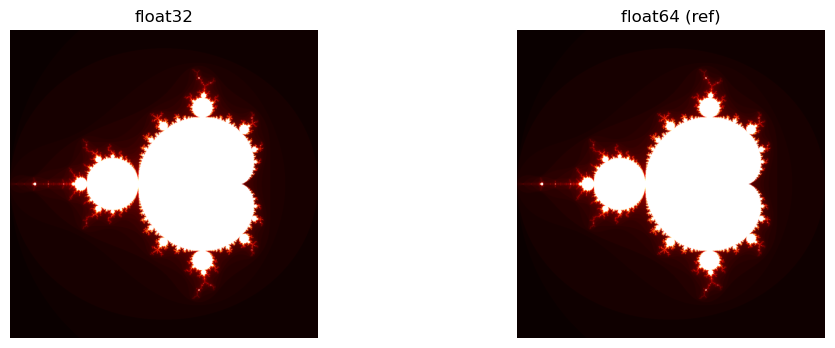

In [5]:
# Parameters
x_dim = (-2, 1)
y_dim = (-1.5, 1.5)
resolution_1 = (64, 64)
resolution_2 = (1024, 1024)

for dtype in [np.float32, np.float64]:
    t0 = time.perf_counter()
    mb3.mandelbrot_numba_typed(x_dim, y_dim, resolution_2, dtype=dtype)
    print(f'{dtype.__name__}: {time.perf_counter()-t0:.3f}s')

r32 = mb3.mandelbrot_numba_typed(x_dim, y_dim, resolution_2, dtype=np.float32)
r64 = mb3.mandelbrot_numba_typed(x_dim, y_dim, resolution_2, dtype=np.float64)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, result, title in zip(axes, [r32, r64], ['float32', 'float64 (ref)']):
    ax.imshow(result, cmap='hot')
    ax.set_title(title)
    ax.axis('off')

plt.savefig('precision_comparison.png', dpi=150)

print(f'Max diff float32 vs float64: {np.abs(r32-r64).max()}')